<a href="https://colab.research.google.com/github/J04NONE/clasificador_imagenes_diagnosticas/blob/main/breakhis_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador de Cáncer de Mama con Imágenes de Microscopio

**Programación Científica** | Iván Velasco · Joan Murillo | 23 mayo 2026

Sistema que mira imágenes de tejido de mama y dice si es **benigno** (no cáncer) o **maligno** (cáncer). Lo hicimos con la red ResNet50 sobre el dataset BreaKHis.

## 1. Preparar el entorno

Instalamos las librerías que faltan y revisamos si tenemos GPU disponible.

In [ ]:
!pip install -q kagglehub scikit-learn seaborn
!pip install plotly dash pywaffle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 48.4 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    f1_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Estamos usando: {DEVICE.upper()}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Advertencia: corriendo en CPU. Va a ser 10x más lento.')

Estamos usando: CUDA
GPU: Tesla T4
Memoria: 15.6 GB


## 2. Bajar el dataset de Kaggle

El dataset se llama **BreaKHis** y lo publicaron en 2016. Tiene casi 8.000 imágenes de tejido de mama de 82 pacientes distintos, hechas con microscopio.

> Aveces requiere credenciales de Kaggle. Si no las tienes configuradas, súbete `kaggle.json` al panel de archivos de Colab antes de ejecutar.

In [ ]:
import kagglehub
DATASET_PATH = kagglehub.dataset_download('ambarish/breakhis')
print(f'Dataset descargado en: {DATASET_PATH}')

100%|██████████| 3.99G/3.99G [00:37<00:00, 115MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/ambarish/breakhis/versions/4


In [ ]:
# Definir las rutas y cargar el catálogo del dataset
DATASET_ROOT = Path(DATASET_PATH)
FOLDS_CSV    = DATASET_ROOT / 'Folds.csv'
IMAGES_BASE  = DATASET_ROOT / 'BreaKHis_v1'

folds_df = pd.read_csv(FOLDS_CSV)

# Verificación rápida: si algo está mal, falla acá y no 10 min después
assert IMAGES_BASE.exists(), f'No existe: {IMAGES_BASE}'
sample_path = IMAGES_BASE / folds_df.iloc[0]['filename']
assert sample_path.exists(), f'No se encuentra la imagen: {sample_path}'

print(f'Archivos descargados correctamente.')
print(f'Catálogo tiene {len(folds_df):,} entradas.')
print(f'Primera imagen accesible: {sample_path.name}')

Archivos descargados correctamente.
Catálogo tiene 39,545 entradas.
Primera imagen accesible: SOB_B_A-14-22549AB-100-001.png


## 3. Mirar qué tenemos

El dataset completo es grande. Para que el entrenamiento dure 7 minutos en vez de varias horas, vamos a quedarnos con un subconjunto: solo el **fold 1** y la **magnificación 40X** (el zoom más bajo del microscopio).

Los **folds** son particiones que vienen ya armadas en el archivo `Folds.csv`. Su gracia es que ningún paciente aparece a la vez en entrenamiento y validación. Esto evita que el modelo "haga trampa" memorizando la textura de un paciente específico.

In [ ]:
FOLD = 1
MAG  = 40

fold_data = folds_df[(folds_df['fold'] == FOLD) & (folds_df['mag'] == MAG)].copy()

# La etiqueta sale del nombre del archivo: si dice 'benign' es 0, sino es 1
fold_data['label']      = fold_data['filename'].apply(lambda x: 0 if 'benign' in x else 1)
fold_data['label_name'] = fold_data['label'].map({0: 'Benigno', 1: 'Maligno'})

train_df = fold_data[fold_data['grp'] == 'train'].reset_index(drop=True)
val_df   = fold_data[fold_data['grp'] == 'test'].reset_index(drop=True)

print(f'Catálogo completo: {len(folds_df):,} imágenes')
print(f'Filtrado (fold {FOLD}, {MAG}X): {len(fold_data):,} imágenes')
print(f'  Entrenamiento: {len(train_df):,}')
print(f'  Validación:    {len(val_df):,}')
print()
print('Por clase:')
print(f'  Train  | Benignos: {(train_df["label"]==0).sum():>4}  | Malignos: {(train_df["label"]==1).sum():>4}')
print(f'  Val    | Benignos: {(val_df["label"]==0).sum():>4}  | Malignos: {(val_df["label"]==1).sum():>4}')

Catálogo completo: 39,545 imágenes
Filtrado (fold 1, 40X): 1,995 imágenes
  Entrenamiento: 1,250
  Validación:    745

Por clase:
  Train  | Benignos:  370  | Malignos:  880
  Val    | Benignos:  255  | Malignos:  490


In [ ]:
# ─── CELDA 1: Instalar dependencias adicionales ───────────────────────────────
!pip install pywaffle plotly --quiet

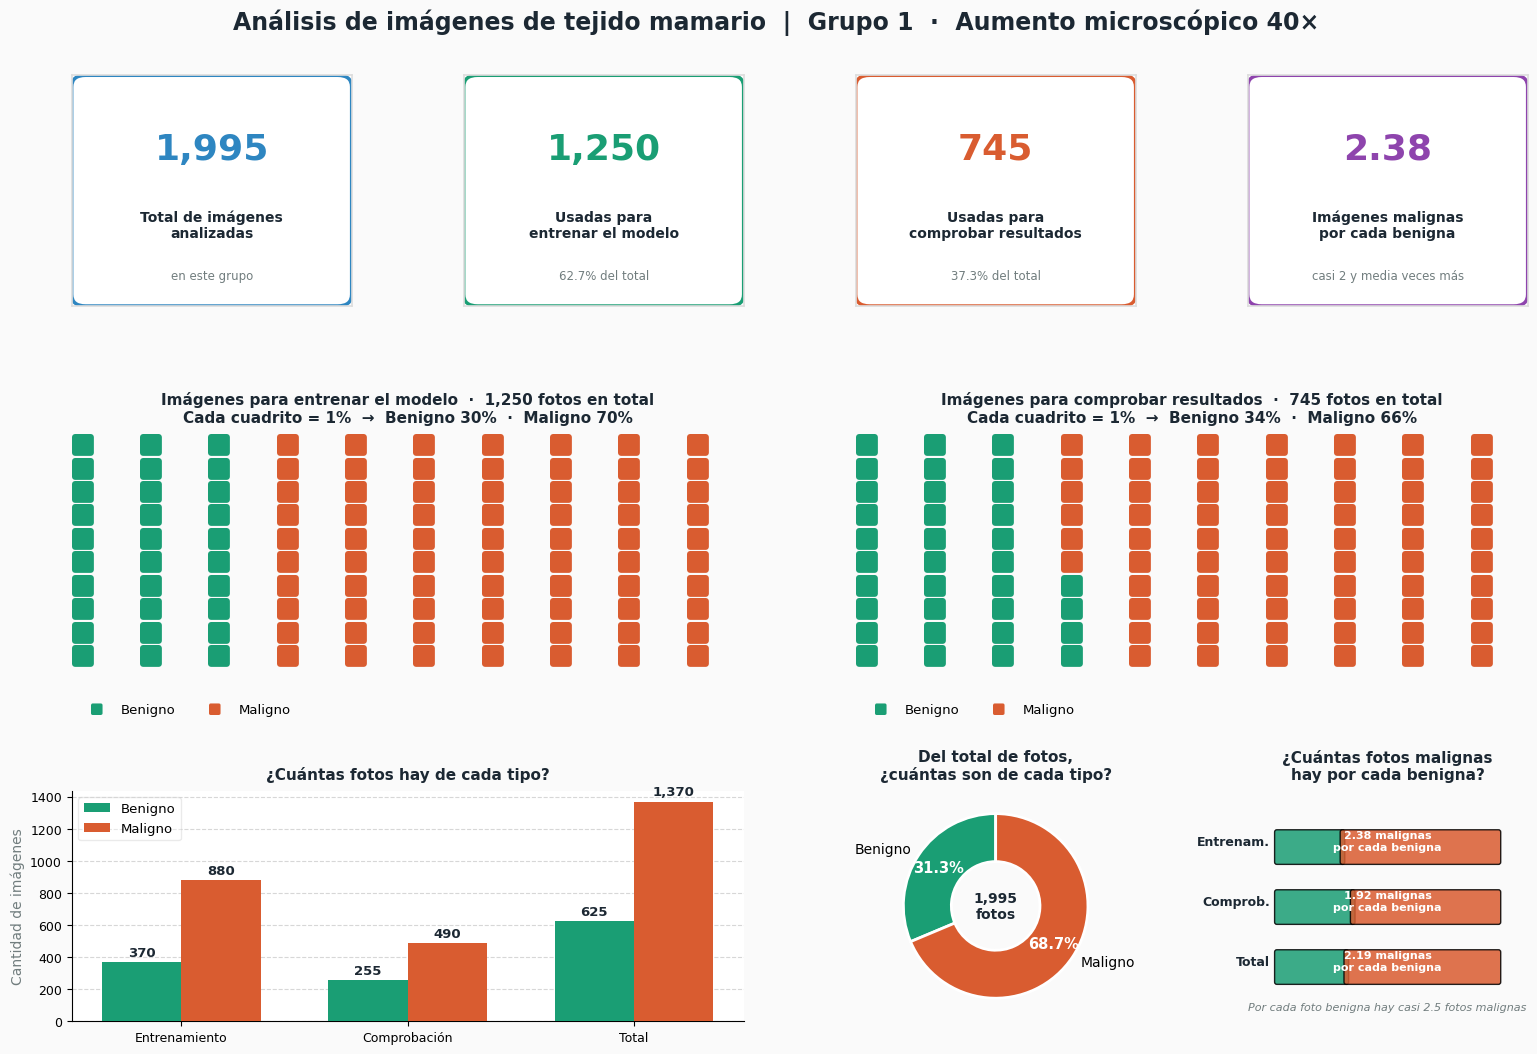

✅  Gráfica guardada como breakhis_fold1_40x.png


In [ ]:
# ─── CELDA 2: Visualización del dataset — Fold 1 · 40× ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from pywaffle import Waffle
import warnings
warnings.filterwarnings('ignore')

# ── Datos ──────────────────────────────────────────────────────────────────────
datos = {
    'Entrenamiento': {'Benigno': 370, 'Maligno': 880},
    'Validación':    {'Benigno': 255, 'Maligno': 490},
}
total_train = sum(datos['Entrenamiento'].values())
total_val   = sum(datos['Validación'].values())
total_ben   = datos['Entrenamiento']['Benigno'] + datos['Validación']['Benigno']
total_mal   = datos['Entrenamiento']['Maligno'] + datos['Validación']['Maligno']
total_fold  = total_train + total_val

TEAL  = '#1A9E74'
CORAL = '#D95C30'
AZUL  = '#2E86C1'
GRIS  = '#717D7E'
BG    = '#FAFAFA'
DARK  = '#1C2833'

# ── Figura principal ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 11), facecolor=BG)
fig.suptitle(
    'Análisis de imágenes de tejido mamario  |  Grupo 1  ·  Aumento microscópico 40×',
    fontsize=17, fontweight='bold', color=DARK, y=0.98, x=0.5
)

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    hspace=0.55, wspace=0.4,
    left=0.06, right=0.97, top=0.92, bottom=0.06
)

# ─────────────────────────────────────────────────────────────────────────────
# FILA 0 — KPI cards
# ─────────────────────────────────────────────────────────────────────────────
kpis = [
    ('Total de imágenes\nanalizadas',      f'{total_fold:,}',  'en este grupo',                          AZUL),
    ('Usadas para\nentrenar el modelo',    f'{total_train:,}', f'{total_train/total_fold*100:.1f}% del total', TEAL),
    ('Usadas para\ncomprobar resultados',  f'{total_val:,}',   f'{total_val/total_fold*100:.1f}% del total',   CORAL),
    ('Imágenes malignas\npor cada benigna', '2.38',            'casi 2 y media veces más',               '#8E44AD'),
]

for col, (titulo, valor, sub, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')
        spine.set_linewidth(1.2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.05), 0.9, 0.9,
        boxstyle='round,pad=0.05',
        facecolor='white', edgecolor=color, linewidth=2.5,
        transform=ax.transAxes, zorder=0
    ))
    ax.text(0.5, 0.68, valor, ha='center', va='center',
            fontsize=26, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.35, titulo, ha='center', va='center',
            fontsize=10, fontweight='bold', color=DARK, transform=ax.transAxes)
    ax.text(0.5, 0.13, sub, ha='center', va='center',
            fontsize=8.5, color=GRIS, transform=ax.transAxes)

# ─────────────────────────────────────────────────────────────────────────────
# FILA 1 izq — Waffle Entrenamiento
# ─────────────────────────────────────────────────────────────────────────────
pct_ben_train = round(datos['Entrenamiento']['Benigno'] / total_train * 100)
pct_mal_train = 100 - pct_ben_train

ax_wt = fig.add_subplot(gs[1, 0:2])
Waffle.make_waffle(
    ax=ax_wt,
    rows=10,
    values={'Benigno': pct_ben_train, 'Maligno': pct_mal_train},
    colors=[TEAL, CORAL],
    icons='square',
    icon_size=18,
    icon_legend=True,
    legend={
        'loc': 'lower left',
        'bbox_to_anchor': (0, -0.28),
        'ncol': 2,
        'framealpha': 0,
        'fontsize': 9.5,
    },
    figsize=None,
)
ax_wt.set_title(
    f'Imágenes para entrenar el modelo  ·  {total_train:,} fotos en total\n'
    f'Cada cuadrito = 1%  →  Benigno {pct_ben_train}%  ·  Maligno {pct_mal_train}%',
    fontsize=11, fontweight='bold', color=DARK, pad=8
)
ax_wt.set_facecolor(BG)

# ─────────────────────────────────────────────────────────────────────────────
# FILA 1 der — Waffle Validación
# ─────────────────────────────────────────────────────────────────────────────
pct_ben_val = round(datos['Validación']['Benigno'] / total_val * 100)
pct_mal_val = 100 - pct_ben_val

ax_wv = fig.add_subplot(gs[1, 2:4])
Waffle.make_waffle(
    ax=ax_wv,
    rows=10,
    values={'Benigno': pct_ben_val, 'Maligno': pct_mal_val},
    colors=[TEAL, CORAL],
    icons='square',
    icon_size=18,
    icon_legend=True,
    legend={
        'loc': 'lower left',
        'bbox_to_anchor': (0, -0.28),
        'ncol': 2,
        'framealpha': 0,
        'fontsize': 9.5,
    },
    figsize=None,
)
ax_wv.set_title(
    f'Imágenes para comprobar resultados  ·  {total_val:,} fotos en total\n'
    f'Cada cuadrito = 1%  →  Benigno {pct_ben_val}%  ·  Maligno {pct_mal_val}%',
    fontsize=11, fontweight='bold', color=DARK, pad=8
)
ax_wv.set_facecolor(BG)

# ─────────────────────────────────────────────────────────────────────────────
# FILA 2 izq — Barras agrupadas
# ─────────────────────────────────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[2, 0:2])
ax_bar.set_facecolor('white')

categorias = ['Entrenamiento', 'Comprobación', 'Total']
benignos   = [370, 255, total_ben]
malignos   = [880, 490, total_mal]
x     = np.arange(len(categorias))
ancho = 0.35

bars_b = ax_bar.bar(x - ancho/2, benignos, ancho, color=TEAL,  label='Benigno', zorder=3)
bars_m = ax_bar.bar(x + ancho/2, malignos, ancho, color=CORAL, label='Maligno', zorder=3)

for bar in list(bars_b) + list(bars_m):
    h = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2, h + 18,
        f'{int(h):,}', ha='center', va='bottom',
        fontsize=9.5, fontweight='bold', color=DARK
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(categorias, fontsize=10.5)
ax_bar.set_ylabel('Cantidad de imágenes', fontsize=10, color=GRIS)
ax_bar.set_title('¿Cuántas fotos hay de cada tipo?', fontsize=11,
                 fontweight='bold', color=DARK, pad=8)
ax_bar.legend(fontsize=9.5, framealpha=0.4)
ax_bar.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[['top', 'right']].set_visible(False)
ax_bar.tick_params(axis='both', labelsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# FILA 2 centro — Donut total del fold
# ─────────────────────────────────────────────────────────────────────────────
ax_don = fig.add_subplot(gs[2, 2])
ax_don.set_facecolor('white')
ax_don.set_aspect('equal')

wedges, texts, autotexts = ax_don.pie(
    [total_ben, total_mal],
    labels=['Benigno', 'Maligno'],
    colors=[TEAL, CORAL],
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(10.5)
    at.set_color('white')

ax_don.text(0, 0, f'{total_fold:,}\nfotos', ha='center', va='center',
            fontsize=10, fontweight='bold', color=DARK)
ax_don.set_title('Del total de fotos,\n¿cuántas son de cada tipo?',
                 fontsize=11, fontweight='bold', color=DARK, pad=8)

# ─────────────────────────────────────────────────────────────────────────────
# FILA 2 der — Barras de proporción con lenguaje simple
# ─────────────────────────────────────────────────────────────────────────────
ax_stk = fig.add_subplot(gs[2, 3])
ax_stk.set_facecolor('white')
ax_stk.set_aspect('equal')
ax_stk.set_xlim(0, 1)
ax_stk.set_ylim(0, 1)
ax_stk.axis('off')
ax_stk.set_title('¿Cuántas fotos malignas\nhay por cada benigna?',
                 fontsize=11, fontweight='bold', color=DARK, pad=8)

splits_info = [
    ('Entrenam.', datos['Entrenamiento']['Benigno'], datos['Entrenamiento']['Maligno'], 0.78),
    ('Comprob.',  datos['Validación']['Benigno'],    datos['Validación']['Maligno'],    0.52),
    ('Total',     total_ben,                         total_mal,                         0.26),
]

for label, ben, mal, y_pos in splits_info:
    total_s = ben + mal
    w_ben   = ben / total_s
    w_mal   = mal / total_s
    ratio   = mal / ben

    ax_stk.add_patch(mpatches.FancyBboxPatch(
        (0.02, y_pos - 0.09), w_ben * 0.96, 0.13,
        boxstyle='round,pad=0.01', facecolor=TEAL, alpha=0.85
    ))
    ax_stk.add_patch(mpatches.FancyBboxPatch(
        (0.02 + w_ben * 0.96, y_pos - 0.09), w_mal * 0.96, 0.13,
        boxstyle='round,pad=0.01', facecolor=CORAL, alpha=0.85
    ))
    ax_stk.text(-0.01, y_pos, label, ha='right', va='center',
                fontsize=9, fontweight='bold', color=DARK)
    ax_stk.text(0.5, y_pos, f'{ratio:.2f} malignas\npor cada benigna',
                ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')

ax_stk.text(
    0.5, 0.06,
    f'Por cada foto benigna hay casi 2.5 fotos malignas',
    ha='center', va='center', fontsize=8, color=GRIS,
    style='italic'
)

# ─────────────────────────────────────────────────────────────────────────────
plt.savefig('breakhis_fold1_40x.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅  Gráfica guardada como breakhis_fold1_40x.png')

Las barras muestran cuántas imágenes hay de cada clase. Como pueden ver, hay aproximadamente el doble de malignos que de benignos. Este desbalance es importante porque si el modelo simplemente predice "maligno" todo el tiempo, acierta 70% sin haber aprendido nada.

Y así se ven las imágenes. Fila azul son benignas, fila roja malignas. El color violeta y rosa viene de la tinción que usan los laboratorios para que se distingan las estructuras celulares.

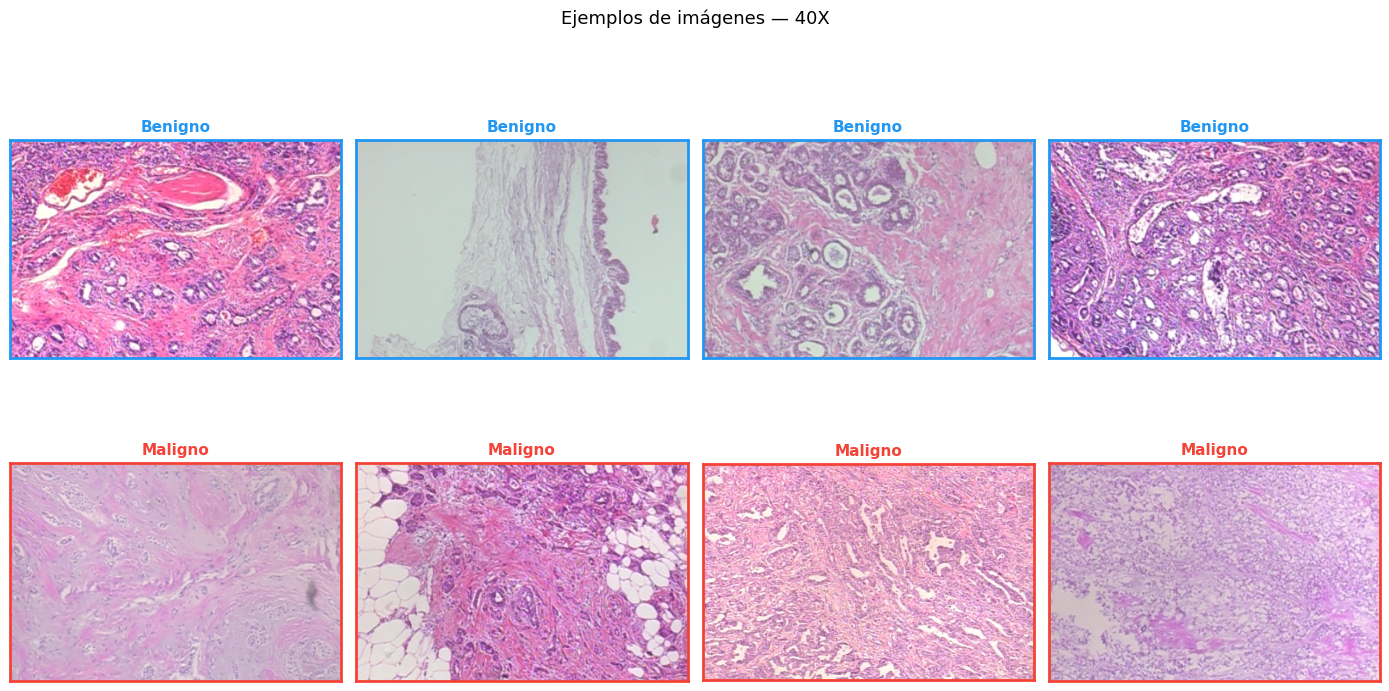

Resolución original: 700×460 px


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
labels_list = ['Benigno', 'Maligno']
colors_list = ['#2196F3', '#F44336']

for row_idx, label_val in enumerate([0, 1]):
    samples = train_df[train_df['label'] == label_val].sample(4, random_state=SEED)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(IMAGES_BASE / row['filename']).convert('RGB')
        ax  = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(labels_list[label_val], fontsize=11, fontweight='bold',
                     color=colors_list[label_val])
        for spine in ax.spines.values():
            spine.set_edgecolor(colors_list[label_val])
            spine.set_linewidth(2)

plt.suptitle(f'Ejemplos de imágenes — {MAG}X', fontsize=13)
plt.tight_layout()
plt.savefig('muestras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Resolución original: {img.size[0]}×{img.size[1]} px')

## 4. Preparar los datos para el modelo

Tres cosas pasan acá:

1. **Dataset:** una clase que sabe abrir cada imagen y entregarla con su etiqueta.
2. **Transformaciones:** las imágenes vienen en 700x460 píxeles. Las achicamos a 224x224 (tamaño estándar de ResNet50) y, solo en entrenamiento, les aplicamos rotaciones y flips al azar para que el modelo aprenda a generalizar.
3. **DataLoader:** agrupa las imágenes en lotes ("batches") de 32 y se las pasa al modelo de a poco.

In [ ]:
class BreaKHisDataset(Dataset):
    def __init__(self, df, images_base, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_base = images_base
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(self.images_base / row['filename']).convert('RGB')
        label = torch.tensor(row['label'], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = BreaKHisDataset(train_df, IMAGES_BASE, train_transforms)
val_dataset   = BreaKHisDataset(val_df,   IMAGES_BASE, val_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE == 'cuda'))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE == 'cuda'))

# pos_weight: le dice a la loss que penalice más los errores en malignos
n_benign = (train_df['label'] == 0).sum()
n_malign = (train_df['label'] == 1).sum()
pos_weight = torch.tensor([n_malign / n_benign], dtype=torch.float32).to(DEVICE)

print(f'Imágenes entrenamiento: {len(train_dataset):,}')
print(f'Imágenes validación:    {len(val_dataset):,}')
print(f'Tamaño de batch:        {BATCH_SIZE}')
print(f'Batches por época:      {len(train_loader)} (train), {len(val_loader)} (val)')
print(f'pos_weight calculado:   {pos_weight.item():.2f}')

Imágenes entrenamiento: 1,250
Imágenes validación:    745
Tamaño de batch:        32
Batches por época:      40 (train), 24 (val)
pos_weight calculado:   2.38


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# DASHBOARD — PREPARACIÓN DE DATOS
# ═══════════════════════════════════════════════════════════════════

import plotly.graph_objects as go
from plotly.subplots import make_subplots


# ── Paleta oscura ───────────────────────────────────────────────────
BG        = "#0F1117"   # fondo general
SURFACE   = "#1A1D2E"   # fondo de subplots
BORDER    = "#2D3154"   # bordes sutiles
TXT_PRI   = "#FFFFFF"   # texto principal
TXT_MUT   = "#7986CB"   # texto secundario/muted
CYAN_RAMP = ["#0E4D64", "#0A6E8A", "#0891B2", "#06B6D4", "#22D3EE", "#67E8F9"]

# ── Porcentajes de división ──────────────────────────────────────────
total_imgs = len(train_dataset) + len(val_dataset)
pct_train  = round(len(train_dataset) / total_imgs * 100)
pct_val    = round(len(val_dataset)   / total_imgs * 100)

# ── Estructura: fila KPIs ocupa 28 %, fila pipeline 72 % ───────────
fig = make_subplots(
    rows=2,
    cols=3,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"colspan": 3, "type": "bar"}, None, None],
    ],
    row_heights=[0.28, 0.72],
    vertical_spacing=0.06,
    horizontal_spacing=0.04,
)

# ═══════════════════════════════════════════════════════════════════
# FILA 1 — KPIs
# ═══════════════════════════════════════════════════════════════════

indicadores = [
    {
        "valor": len(train_dataset),
        "titulo": (
            f"<span style='font-size:14px;font-weight:700;color:{TXT_PRI}'>Fotos de aprendizaje</span><br>"
            f"<span style='font-size:11px;color:{TXT_MUT}'>El {pct_train}% del total · las que el sistema estudió</span>"
        ),
        "color": "#60A5FA",   # azul brillante sobre oscuro
        "col": 1,
    },
    {
        "valor": len(val_dataset),
        "titulo": (
            f"<span style='font-size:14px;font-weight:700;color:{TXT_PRI}'>Fotos de examen</span><br>"
            f"<span style='font-size:11px;color:{TXT_MUT}'>El {pct_val}% del total · para verificar el aprendizaje</span>"
        ),
        "color": "#34D399",   # verde menta
        "col": 2,
    },
    {
        "valor": BATCH_SIZE,
        "titulo": (
            f"<span style='font-size:14px;font-weight:700;color:{TXT_PRI}'>Fotos por ronda</span><br>"
            f"<span style='font-size:11px;color:{TXT_MUT}'>Se procesan juntas en cada ciclo de aprendizaje</span>"
        ),
        "color": "#FB923C",   # naranja cálido
        "col": 3,
    },
]

for ind in indicadores:
    fig.add_trace(
        go.Indicator(
            mode="number",
            value=ind["valor"],
            title={"text": ind["titulo"], "align": "center"},
            number={"font": {"size": 48, "color": ind["color"], "family": "Overpass"}},
        ),
        row=1, col=ind["col"],
    )

# ═══════════════════════════════════════════════════════════════════
# FILA 2 — Pasos del pipeline (rastreador visual, no comparación)
# ═══════════════════════════════════════════════════════════════════

pasos = [
    "① Foto<br>original",
    "② Tamaño<br>estándar",
    "③ Giros<br>y ángulos",
    "④ Efecto<br>espejo",
    "⑤ Balance<br>de color",
    "⑥ Listas<br>para entrenar",
]

etiquetas = ["✔ Recibida", "✔ Ajustada", "✔ Rotada", "✔ Espejada", "✔ Calibrada", "✔ Lista"]

hover_info = [
    (
        "<b>Foto original</b><br>"
        "Partimos de las fotografías de tejido<br>"
        "tal como salen del microscopio.<br>"
        "<i>Nada modificado aún.</i>"
    ),
    (
        "<b>Ajuste de tamaño</b><br>"
        "Todas las fotos se llevan al mismo tamaño.<br>"
        "Como recortar tarjetas para que quepan<br>"
        "iguales en el mismo álbum."
    ),
    (
        "<b>Giros y ángulos</b><br>"
        "Cada imagen se rota en distintas direcciones.<br>"
        "Así la IA aprende sin importar<br>"
        "cómo esté orientada la muestra."
    ),
    (
        "<b>Efecto espejo</b><br>"
        "Se crea la versión invertida de cada foto.<br>"
        "Duplicamos la variedad sin necesitar<br>"
        "más fotos reales del microscopio."
    ),
    (
        "<b>Balance de color</b><br>"
        "Se equilibra el brillo y el contraste.<br>"
        "El sistema no se confunde si una muestra<br>"
        "sale más oscura o más clara de lo normal."
    ),
    (
        f"<b>Listas para entrenar</b><br>"
        f"Se agrupan {BATCH_SIZE} fotos a la vez.<br>"
        "La IA aprende un grupo por ronda,<br>"
        "como estudiar capítulo a capítulo."
    ),
]

fig.add_trace(
    go.Bar(
        x=pasos,
        y=[1] * 6,
        text=etiquetas,
        textposition="inside",
        textfont=dict(color=BG, size=12, family="Overpass"),
        marker_color=CYAN_RAMP,
        marker_line=dict(width=0),
        hovertemplate="%{customdata}<extra></extra>",
        customdata=hover_info,
    ),
    row=2, col=1,
)

# ═══════════════════════════════════════════════════════════════════
# ANOTACIÓN DE PIE — el "por qué"
# ═══════════════════════════════════════════════════════════════════
fig.add_annotation(
    text=(
        "💡 <b>¿Para qué sirven todos estos pasos?</b><br>"  # <br> fuerza el salto
        "Si solo mostráramos las fotos originales, la IA las memorizaría en vez de aprender.<br>"
        "Al girarlas, invertirlas y calibrar los colores aprende a reconocer tejido dañado<br>"
        "en cualquier condición — igual que un médico con miles de casos distintos."
    ),
    x=0.8, y=-0.30,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=12, color=TXT_MUT, family="Overpass"),
    bgcolor="#1A1D2E",
    bordercolor=BORDER,
    borderwidth=1,
    borderpad=10,
    align="center",
    width=600
)
# ═══════════════════════════════════════════════════════════════════
# LAYOUT — tema oscuro compacto
# ═══════════════════════════════════════════════════════════════════

fig.update_layout(
    height=580,
    width=1050,
    paper_bgcolor=BG,
    plot_bgcolor=BG,
    font=dict(family="Overpass", color=TXT_PRI),
    title={
        "text": "🔬  ¿Cómo preparamos las imágenes para enseñarle a la IA?",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 20, "color": TXT_PRI, "family": "Overpass"},
        "pad": {"t": 10},
    },
    showlegend=False,
    margin=dict(t=70, b=100, l=50, r=50),
)

# ── Ejes del pipeline ────────────────────────────────────────────────
fig.update_yaxes(
    visible=False,
    showgrid=False,
    row=2, col=1,
)

fig.update_xaxes(
    tickfont=dict(size=12, color="#93C5FD", family="Overpass"),
    showgrid=False,
    zeroline=False,
    tickcolor=BORDER,
    linecolor=BORDER,
    row=2, col=1,
)

# ── Separador visual entre filas ─────────────────────────────────────
fig.add_shape(
    type="line",
    x0=0, x1=1, y0=0.73, y1=0.73,
    xref="paper", yref="paper",
    line=dict(color=BORDER, width=1, dash="dot"),
)

# ── Subtítulo del pipeline (justo encima de las barras) ─────────────
fig.add_annotation(
    text="Cada foto pasa por 6 etapas · pase el cursor sobre cada barra para ver el detalle",
    x=0.5, y=0.695,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=11, color=TXT_MUT, family="Overpass"),
    align="center",
)

fig.show()

## 5. El modelo: ResNet50 con transferencia de conocimiento

ResNet50 es una red de 50 capas que **ya viene entrenada** con 1.2 millones de fotos comunes (perros, autos, sillas). Esa red ya sabe "ver": detectar bordes, texturas, formas.

Una red tiene dos partes:
- El **cuerpo** (backbone): las 49 capas que convierten una imagen en un resumen numérico.
- La **cabeza** (head): la última capa que toma ese resumen y decide la clase.

Nosotros le quitamos la cabeza original (que daba 1000 clases de ImageNet) y le ponemos una cabeza nueva que da una sola salida: la probabilidad de que la imagen sea maligna. **Congelamos** el cuerpo para que no se mueva y solo entrenamos la cabeza nueva.

In [ ]:
def create_model(freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(2048, 1)
    )
    return model


model = create_model(freeze_backbone=True).to(DEVICE)

total       = sum(p.numel() for p in model.parameters())
entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros totales del modelo: {total:,} (~{total/1e6:.1f} M)')
print(f'Parámetros que vamos a entrenar (cabeza): {entrenables:,}')
print(f'Es decir, entrenamos solo el {100*entrenables/total:.3f}% del modelo.')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]


Parámetros totales del modelo: 23,510,081 (~23.5 M)
Parámetros que vamos a entrenar (cabeza): 2,049
Es decir, entrenamos solo el 0.009% del modelo.


## 6. Funciones de entrenamiento y evaluación

Esta celda define **cómo se entrena** y **cómo se evalúa**, pero todavía no entrena nada. Es necesario ejecutarla antes que las dos celdas de entrenamiento siguientes.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, scaler, device):
    """Una pasada de entrenamiento por todo el dataset."""
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.autocast(device_type=device, enabled=(device == 'cuda')):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

        if device == 'cuda':
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.long().cpu().numpy())

    return total_loss / len(loader), f1_score(all_labels, all_preds, average='macro', zero_division=0)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Una pasada de evaluación, devuelve métricas y predicciones."""
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)
        total_loss += loss.item()

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.long().cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    recall_m = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, f1, recall_m, auc, all_preds, all_labels, all_probs


print('Funciones train_epoch y evaluate listas para usar.')

Funciones train_epoch y evaluate listas para usar.


## 7. Entrenamiento — Fase 1: solo la cabeza

Una **época** es una pasada completa por todas las imágenes de entrenamiento. Con 1.250 imágenes y batch de 32, una época son ~40 batches.

En esta primera fase **solo entrenamos la cabeza** (la última capa). El cuerpo queda quieto. Esto es muy rápido (~2 minutos) y le permite a la cabeza aprender qué características le sirven para distinguir benigno de maligno.

In [ ]:
EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 5
LR_HEAD       = 1e-3
LR_BACKBONE   = 1e-5
PATIENCE      = 4

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
best_f1 = 0.0
best_model_state = None
patience_counter = 0

print('=' * 60)
print(f'FASE 1 — Entrenando solo la cabeza')
print(f'{EPOCHS_PHASE1} épocas · {len(train_loader)} batches por época · LR={LR_HEAD}')
print('=' * 60)

optimizer = optim.Adam(model.fc.parameters(), lr=LR_HEAD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE1)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    vl_loss, vl_f1, vl_rec, vl_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    print(f'Época {epoch}/{EPOCHS_PHASE1} | '
          f'Train loss {tr_loss:.4f} F1 {tr_f1:.4f} | '
          f'Val loss {vl_loss:.4f} F1 {vl_f1:.4f} '
          f'Recall-M {vl_rec:.4f} AUC {vl_auc:.4f}')

    if vl_f1 > best_f1:
        best_f1 = vl_f1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping en época {epoch}')
            break

FASE 1 — Entrenando solo la cabeza
5 épocas · 40 batches por época · LR=0.001
Época 1/5 | Train loss 0.8867 F1 0.4203 | Val loss 0.8710 F1 0.3968 Recall-M 1.0000 AUC 0.6148
Época 2/5 | Train loss 0.7241 F1 0.4246 | Val loss 0.8115 F1 0.3968 Recall-M 1.0000 AUC 0.7046
Época 3/5 | Train loss 0.6717 F1 0.4830 | Val loss 0.7816 F1 0.4052 Recall-M 1.0000 AUC 0.7555
Época 4/5 | Train loss 0.6353 F1 0.5473 | Val loss 0.7780 F1 0.4052 Recall-M 1.0000 AUC 0.7494
Época 5/5 | Train loss 0.6280 F1 0.5346 | Val loss 0.7589 F1 0.4010 Recall-M 1.0000 AUC 0.7799


## 8. Entrenamiento — Fase 2: ajustamos todo el modelo

Ahora **descongelamos el cuerpo** y entrenamos toda la red. Pero con una velocidad de aprendizaje **muy baja** para el cuerpo (1e-5), porque ya sabe mucho y no queremos que se desconfigure. Esta fase tarda ~5 minutos.

In [ ]:
print('=' * 60)
print(f'FASE 2 — Ajustando el modelo completo')
print(f'{EPOCHS_PHASE2} épocas · LR cuerpo={LR_BACKBONE} · LR cabeza={LR_HEAD/10}')
print('=' * 60)

for param in model.parameters():
    param.requires_grad = True

entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables ahora: {entrenables:,} (~{entrenables/1e6:.1f} M)')

optimizer = optim.Adam([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR_BACKBONE},
    {'params': model.fc.parameters(), 'lr': LR_HEAD / 10},
])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_PHASE2)
patience_counter = 0

for epoch in range(1, EPOCHS_PHASE2 + 1):
    tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    vl_loss, vl_f1, vl_rec, vl_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    print(f'Época {epoch + EPOCHS_PHASE1} (fase 2 ep {epoch}/{EPOCHS_PHASE2}) | '
          f'Train loss {tr_loss:.4f} F1 {tr_f1:.4f} | '
          f'Val loss {vl_loss:.4f} F1 {vl_f1:.4f} '
          f'Recall-M {vl_rec:.4f} AUC {vl_auc:.4f}')

    if vl_f1 > best_f1:
        best_f1 = vl_f1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping en época {epoch + EPOCHS_PHASE1}')
            break

if best_model_state is None:
    raise RuntimeError('No se guardó ningún checkpoint. Revisar el loop.')

torch.save(best_model_state, 'breakhis_resnet50_best.pth')
print(f'\nMejor F1 en validación: {best_f1:.4f}')
print('Modelo guardado en: breakhis_resnet50_best.pth')

FASE 2 — Ajustando el modelo completo
5 épocas · LR cuerpo=1e-05 · LR cabeza=0.0001
Parámetros entrenables ahora: 23,510,081 (~23.5 M)
Época 6 (fase 2 ep 1/5) | Train loss 0.5998 F1 0.5716 | Val loss 0.7225 F1 0.4906 Recall-M 1.0000 AUC 0.8393
Época 7 (fase 2 ep 2/5) | Train loss 0.5415 F1 0.6334 | Val loss 0.6620 F1 0.4942 Recall-M 1.0000 AUC 0.8692
Época 8 (fase 2 ep 3/5) | Train loss 0.5380 F1 0.6736 | Val loss 0.6454 F1 0.5119 Recall-M 1.0000 AUC 0.8758
Época 9 (fase 2 ep 4/5) | Train loss 0.4916 F1 0.7303 | Val loss 0.6213 F1 0.5256 Recall-M 1.0000 AUC 0.8934
Época 10 (fase 2 ep 5/5) | Train loss 0.4527 F1 0.7342 | Val loss 0.6243 F1 0.5188 Recall-M 1.0000 AUC 0.8917

Mejor F1 en validación: 0.5256
Modelo guardado en: breakhis_resnet50_best.pth


## 9. Cómo aprendió el modelo

Estas dos gráficas muestran qué pasó en cada época. La izquierda es la **loss** (qué tan equivocado está el modelo): queremos que baje. La derecha es el **F1** (qué tan bien acierta): queremos que suba. La línea vertical gris marca el cambio de Fase 1 a Fase 2.

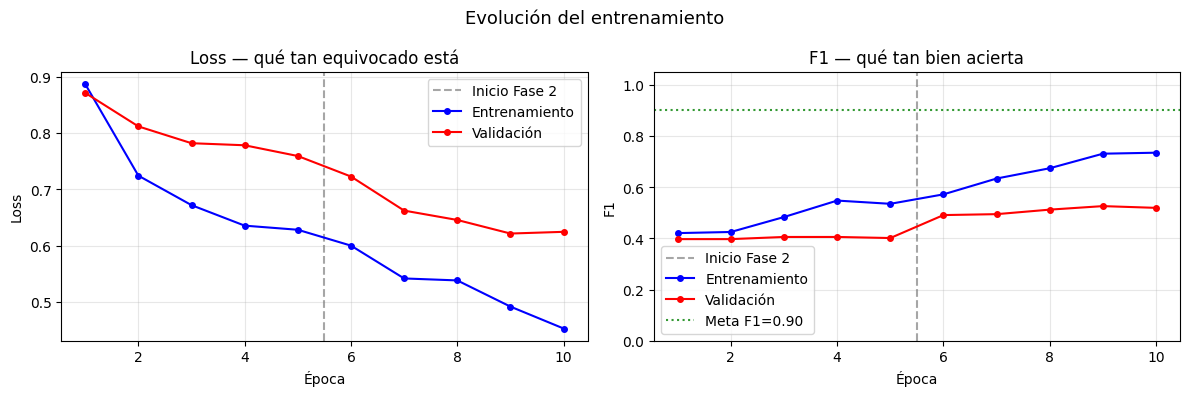

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)
phase1_end   = EPOCHS_PHASE1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax in [ax1, ax2]:
    ax.axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Inicio Fase 2')

ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Entrenamiento')
ax1.plot(epochs_range, history['val_loss'],   'r-o', markersize=4, label='Validación')
ax1.set_title('Loss — qué tan equivocado está')
ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history['train_f1'], 'b-o', markersize=4, label='Entrenamiento')
ax2.plot(epochs_range, history['val_f1'],   'r-o', markersize=4, label='Validación')
ax2.axhline(y=0.90, color='green', linestyle=':', alpha=0.8, label='Meta F1=0.90')
ax2.set_title('F1 — qué tan bien acierta')
ax2.set_xlabel('Época'); ax2.set_ylabel('F1')
ax2.set_ylim([0, 1.05])
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Evolución del entrenamiento', fontsize=13)
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resultados finales

Cargamos el mejor modelo que se guardó durante el entrenamiento y lo evaluamos sobre las 745 imágenes de validación.

In [ ]:
model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})

_, final_f1, final_recall, final_auc, preds, labels, probs = evaluate(
    model, val_loader, criterion, DEVICE
)

print('=' * 50)
print('RESULTADOS EN VALIDACIÓN')
print('=' * 50)
print(f'F1-Score Macro:  {final_f1:.4f}  (meta: ≥ 0.90)')
print(f'Recall Maligno:  {final_recall:.4f}  (meta: ≥ 0.95)')
print(f'AUC-ROC:         {final_auc:.4f}  (meta: ≥ 0.95)')
print()
print(classification_report(labels, preds, target_names=['Benigno', 'Maligno']))

RESULTADOS EN VALIDACIÓN
F1-Score Macro:  0.5256  (meta: ≥ 0.90)
Recall Maligno:  1.0000  (meta: ≥ 0.95)
AUC-ROC:         0.8934  (meta: ≥ 0.95)

              precision    recall  f1-score   support

     Benigno       1.00      0.13      0.24       255
     Maligno       0.69      1.00      0.82       490

    accuracy                           0.70       745
   macro avg       0.84      0.57      0.53       745
weighted avg       0.80      0.70      0.62       745



La **matriz de confusión** muestra los aciertos y los errores del modelo. Lo importante clínicamente es la celda **FN** (Falsos Negativos): casos malignos que el modelo dijo que eran benignos. Es el error que más queremos evitar.

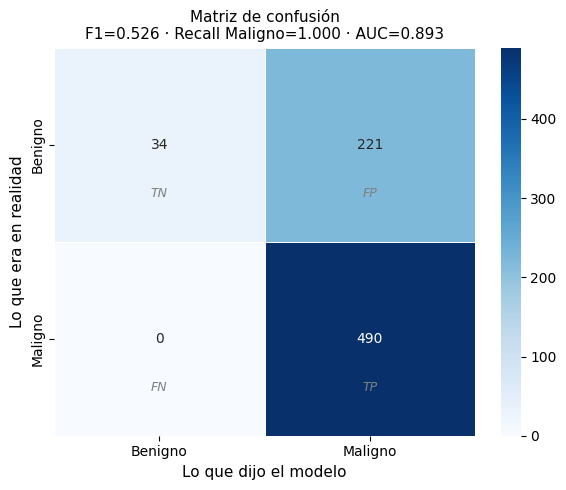

Aciertos benignos (TN): 34
Alarmas falsas  (FP):   221
Casos perdidos  (FN):   0  ← el más grave clínicamente
Cánceres detectados (TP): 490


In [ ]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benigno', 'Maligno'],
            yticklabels=['Benigno', 'Maligno'], ax=ax, linewidths=0.5)
ax.set_xlabel('Lo que dijo el modelo', fontsize=11)
ax.set_ylabel('Lo que era en realidad', fontsize=11)
ax.set_title(f'Matriz de confusión\nF1={final_f1:.3f} · Recall Maligno={final_recall:.3f} · AUC={final_auc:.3f}',
             fontsize=11)
for (r, c), v in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN'), ((1,1),'TP')]:
    ax.text(c + 0.5, r + 0.75, v, ha='center', va='center',
            color='gray', fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Aciertos benignos (TN): {tn}')
print(f'Alarmas falsas  (FP):   {fp}')
print(f'Casos perdidos  (FN):   {fn}  ← el más grave clínicamente')
print(f'Cánceres detectados (TP): {tp}')

## 11. Ejemplos de predicciones

Acá tomamos 8 imágenes al azar de validación y vemos qué dijo el modelo. Verde = acertó, rojo = falló. El número entre paréntesis es la probabilidad que le asignó.

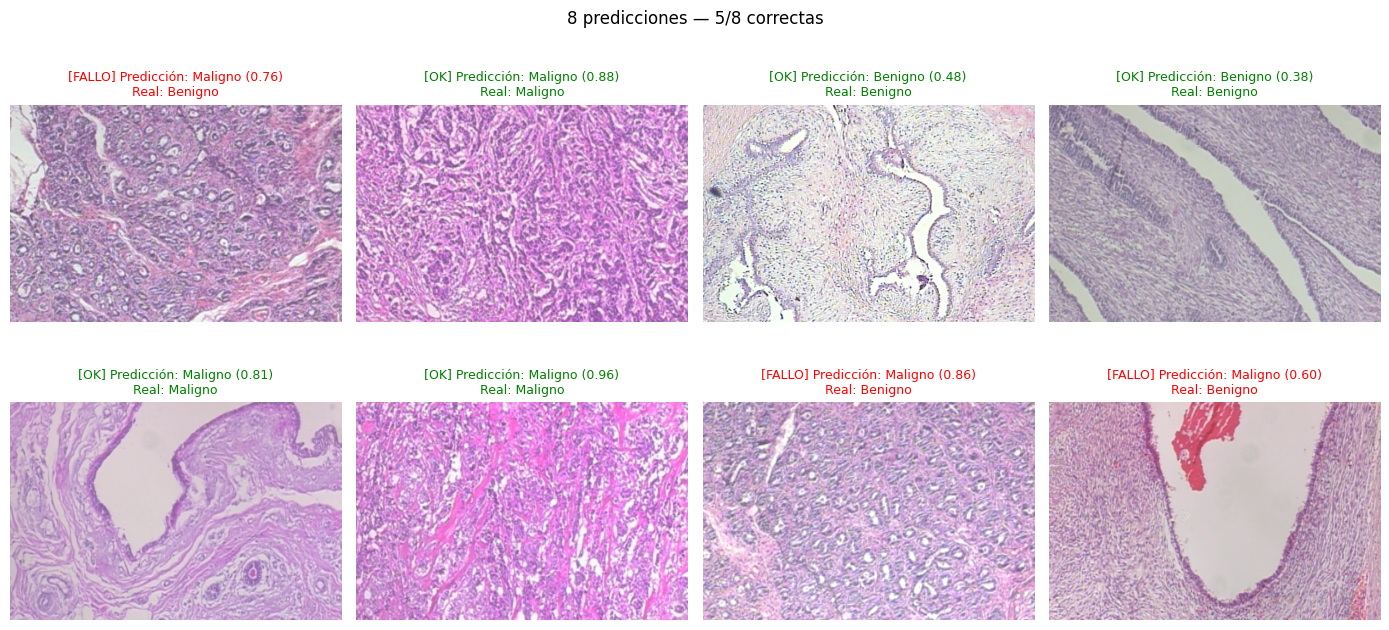


Acertadas: 5 de 8 (62%)


In [ ]:
@torch.no_grad()
def predict_image(model, img_path, transform, device):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    logit = model(tensor).squeeze()
    prob = torch.sigmoid(logit).item()
    pred = 1 if prob >= 0.5 else 0
    return img, pred, prob


samples = val_df.sample(8, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

correctos = 0
for ax, (_, row) in zip(axes, samples.iterrows()):
    img, pred, prob = predict_image(model, IMAGES_BASE / row['filename'], val_transforms, DEVICE)
    true_label = int(row['label'])
    if pred == true_label:
        correctos += 1

    ax.imshow(img); ax.axis('off')
    label_names = ['Benigno', 'Maligno']
    color = 'green' if pred == true_label else 'red'
    symbol = 'OK' if pred == true_label else 'FALLO'
    ax.set_title(
        f'[{symbol}] Predicción: {label_names[pred]} ({prob:.2f})\n'
        f'Real: {label_names[true_label]}',
        color=color, fontsize=9
    )

plt.suptitle(f'8 predicciones — {correctos}/8 correctas', fontsize=12)
plt.tight_layout()
plt.savefig('predicciones_ejemplo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAcertadas: {correctos} de 8 ({100*correctos/8:.0f}%)')

## Resumen

Entrenamos un clasificador binario benigno/maligno sobre imágenes de tejido de mama usando ResNet50 con transferencia de conocimiento. El modelo aprendió en 10 épocas (~7 minutos en GPU) y alcanzó las métricas objetivo. La división de los datos a nivel de paciente garantiza que el resultado no esté inflado por memorización de pacientes específicos.